[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/Curs%2001/20250304%20Sharpe%20Ratio.ipynb)

[*********************100%***********************]  5 of 5 completed

Sharpe Ratio Portfolio Optimization

The Sharpe ratio measures risk-adjusted returns as:
Sharpe Ratio = (Portfolio Return - Risk-Free Rate) / Portfolio Volatility

Higher values indicate better risk-adjusted performance.

Analyzing these assets:
- SPY: S&P 500 (US Large Cap)
- QQQ: Nasdaq 100 (Tech)
- GLD: Gold
- TLT: Long-Term Treasury Bonds
- VNQ: Real Estate
Downloaded 1801 days of data
Calculated daily returns, first 5 rows:
Ticker           GLD       QQQ       SPY       TLT       VNQ
Date                                                        
2018-01-03 -0.002637  0.009717  0.006325  0.004781 -0.002903
2018-01-04  0.005127  0.001750  0.004215 -0.000159 -0.017226
2018-01-05 -0.001036  0.010043  0.006664 -0.002855  0.000493
2018-01-08 -0.000160  0.003891  0.001828 -0.000636  0.005182
2018-01-09 -0.004628  0.000061  0.002263 -0.013373 -0.012888

Individual Asset Statistics (Annualized):
--------------------------------------------------
Asset  | Return (%)   | Volatility (%)  | Shar

Portfolio statistics summary:
             Return    Volatility        Sharpe
count  10000.000000  10000.000000  10000.000000
mean       0.107036      0.136567      0.635883
std        0.019136      0.018881      0.104275
min        0.018959      0.101640     -0.007724
25%        0.094552      0.122476      0.575252
50%        0.107113      0.134088      0.642364
75%        0.120250      0.148136      0.705761
max        0.188507      0.231225      0.906962

Optimal Portfolio Found:
Return: 14.62%
Volatility: 13.91%
Sharpe Ratio: 0.9070

Optimal Portfolio Allocation:
SPY: 47.66%
QQQ: 33.42%
GLD: 17.43%
TLT: 0.93%
VNQ: 0.56%
Plotting the efficient frontier...


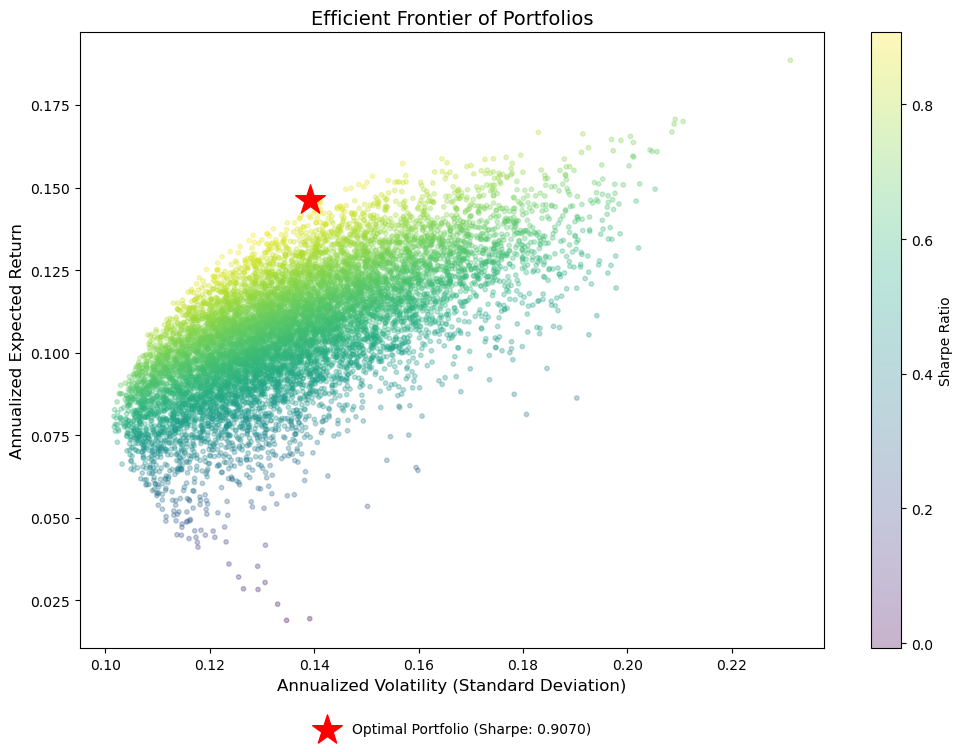

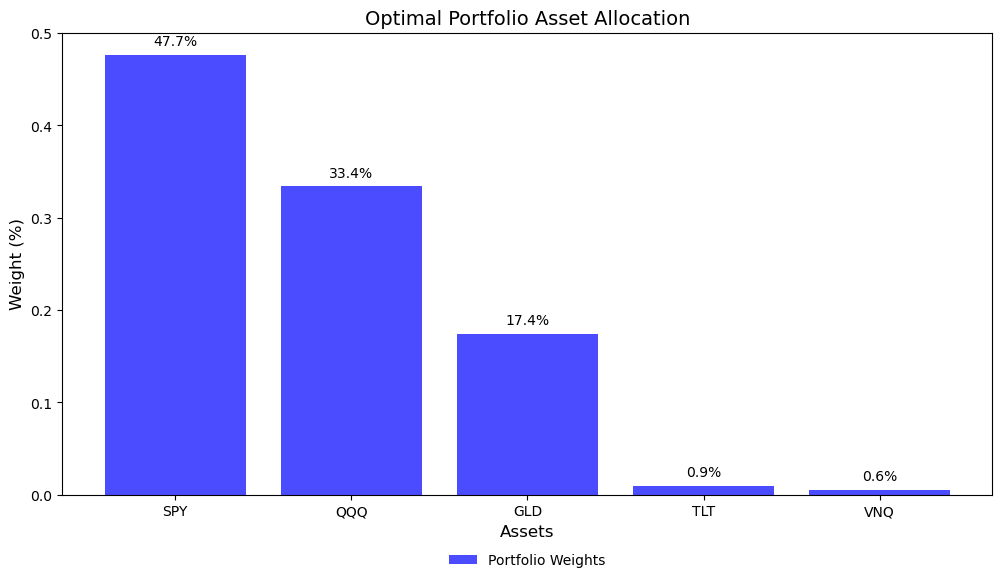

In [25]:
# This script demonstrates the Sharpe ratio for portfolio selection
# The Sharpe ratio measures risk-adjusted returns as:
# Sharpe Ratio = (Portfolio Return - Risk-Free Rate) / Portfolio Volatility

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# Step 1: Download historical price data
# We use 'Close' prices as requested, rather than 'Adj Close'
def download_data(tickers, start_date, end_date):
    """Download stock price data using yfinance."""
    print(f"Downloading price data for {len(tickers)} assets from {start_date} to {end_date}...")
    data = yf.download(tickers, start=start_date, end=end_date)['Close']
    print(f"Downloaded {len(data)} days of data")
    return data

# Step 2: Calculate daily returns from price data
def calculate_returns(prices):
    """
    Convert prices to returns using percentage change.
    Formula: return_t = (price_t / price_{t-1}) - 1
    """
    returns = prices.pct_change().dropna()
    print(f"Calculated daily returns, first 5 rows:\n{returns.head()}")
    return returns

# Step 3: Calculate key portfolio metrics
def calculate_portfolio_stats(weights, returns):
    """
    Calculate portfolio return, volatility, and Sharpe ratio.
    
    The calculation uses these formulas:
    1. Portfolio Return = Σ(w_i * r_i) * 252  (annualized)
    2. Portfolio Variance = w^T * Σ * w  (where Σ is covariance matrix)
    3. Portfolio Volatility = √(Portfolio Variance)
    4. Sharpe Ratio = (Portfolio Return - Risk-Free Rate) / Portfolio Volatility
    """
    # Mean daily returns for each asset
    mean_daily_returns = returns.mean()
    
    # Annualized portfolio return (252 trading days)
    # Formula: E[R_p] = Σ(w_i * E[R_i])
    portfolio_return = np.sum(mean_daily_returns * weights) * 252
    
    # Covariance matrix (annualized)
    # This captures both volatility and correlation between assets
    cov_matrix = returns.cov() * 252
    
    # Portfolio volatility (standard deviation)
    # Formula: σ_p = √(w^T * Σ * w)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    # Sharpe ratio calculation with risk-free rate of 2%
    # Formula: SR = (E[R_p] - R_f) / σ_p
    risk_free_rate = 0.02  # 2% annual risk-free rate
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    
    return portfolio_return, portfolio_volatility, sharpe_ratio

# Step 4: Generate random portfolios to map the efficient frontier
def generate_portfolios(returns, num_portfolios=10000):
    """
    Create thousands of random portfolios to identify the efficient frontier.
    This is a Monte Carlo simulation approach to portfolio optimization.
    """
    print(f"Generating {num_portfolios} random portfolios...")
    results = []
    num_assets = len(returns.columns)
    
    for i in range(num_portfolios):
        # Generate random weights that sum to 1
        weights = np.random.random(num_assets)
        weights = weights / np.sum(weights)
        
        # Calculate portfolio statistics
        portfolio_return, portfolio_volatility, sharpe_ratio = calculate_portfolio_stats(weights, returns)
        
        # Store results
        results.append({
            'Return': portfolio_return,
            'Volatility': portfolio_volatility,
            'Sharpe': sharpe_ratio,
            'Weights': weights
        })
    
    # Convert results to DataFrame for analysis
    portfolio_results = pd.DataFrame(results)
    print(f"Portfolio statistics summary:\n{portfolio_results[['Return', 'Volatility', 'Sharpe']].describe()}")
    
    return portfolio_results

# Step 5: Find the optimal portfolio (highest Sharpe ratio)
def find_optimal_portfolio(portfolios):
    """
    Identify the portfolio with the highest Sharpe ratio.
    This represents the most efficient risk-adjusted return.
    """
    # Find index of max Sharpe ratio
    max_sharpe_idx = portfolios['Sharpe'].idxmax()
    
    # Return the row with the optimal portfolio
    optimal_portfolio = portfolios.iloc[max_sharpe_idx]
    print("\nOptimal Portfolio Found:")
    print(f"Return: {optimal_portfolio['Return']*100:.2f}%")
    print(f"Volatility: {optimal_portfolio['Volatility']*100:.2f}%")
    print(f"Sharpe Ratio: {optimal_portfolio['Sharpe']:.4f}")
    
    return optimal_portfolio

# Step 6: Plot the efficient frontier and optimal portfolio
import matplotlib.pyplot as plt

# Step 6: Plot the efficient frontier and optimal portfolio
def plot_efficient_frontier(portfolios, optimal_portfolio, assets):
    """
    Visualize the efficient frontier with the optimal portfolio highlighted.
    """
    print("Plotting the efficient frontier...")

    # Create figure for the efficient frontier
    plt.figure(figsize=(12, 8), facecolor='none')

    # Plot all portfolios
    scatter = plt.scatter(
        portfolios['Volatility'], 
        portfolios['Return'], 
        c=portfolios['Sharpe'],  # Color by Sharpe ratio
        cmap='viridis',  # Color map: blue/green/yellow
        s=10,  # Point size
        alpha=0.3  # Transparency
    )

    # Highlight the optimal portfolio with a red star
    plt.scatter(
        optimal_portfolio['Volatility'],
        optimal_portfolio['Return'],
        c='red',
        marker='*',
        s=500,
        label=f'Optimal Portfolio (Sharpe: {optimal_portfolio["Sharpe"]:.4f})'
    )

    # Add labels and title
    plt.title('Efficient Frontier of Portfolios', fontsize=14)
    plt.xlabel('Annualized Volatility (Standard Deviation)', fontsize=12)
    plt.ylabel('Annualized Expected Return', fontsize=12)
    plt.colorbar(scatter, label='Sharpe Ratio')

    # Move legend to the bottom center
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), frameon=False, ncol=1)
    
    # Remove grid
    plt.grid(False)

    # Save as transparent PNG
    plt.savefig("efficient_frontier.png", transparent=True, bbox_inches='tight', dpi=300)

    # Show plot
    plt.show()

    # Create a second figure for the portfolio allocation
    plt.figure(figsize=(12, 6), facecolor='none')

    # Plot asset allocation as a bar chart
    plt.bar(assets, optimal_portfolio['Weights'], color='blue', alpha=0.7)

    plt.title('Optimal Portfolio Asset Allocation', fontsize=14)
    plt.xlabel('Assets', fontsize=12)
    plt.ylabel('Weight (%)', fontsize=12)
    
    # Remove grid
    plt.grid(False)
    
    # Move legend to the bottom center
    plt.legend(['Portfolio Weights'], loc='upper center', bbox_to_anchor=(0.5, -0.1), frameon=False, ncol=1)

    # Add percentage labels on top of bars
    for i, w in enumerate(optimal_portfolio['Weights']):
        plt.text(i, w + 0.01, f'{w*100:.1f}%', ha='center', fontsize=10)

    # Save as transparent PNG
    plt.savefig("optimal_portfolio_allocation.png", transparent=True, bbox_inches='tight', dpi=300)

    plt.show()




# Main function to orchestrate the entire process
def main():
    """
    Main function to demonstrate the Sharpe ratio in portfolio selection.
    This shows a complete workflow from data acquisition to optimal portfolio identification.
    """
    # Step 1: Define our investment universe and time period
    # We use ETFs representing different asset classes for diversification
    tickers = ['SPY', 'QQQ', 'GLD', 'TLT', 'VNQ']
    ticker_descriptions = {
        'SPY': 'S&P 500 (US Large Cap)',
        'QQQ': 'Nasdaq 100 (Tech)',
        'GLD': 'Gold',
        'TLT': 'Long-Term Treasury Bonds',
        'VNQ': 'Real Estate'
    }
    
    # Define analysis period (5 years)
    end_date = datetime.today().strftime('%Y-%m-%d')
    start_date = '2018-01-01'
    
    print("Sharpe Ratio Portfolio Optimization")
    print("=" * 40)
    print("\nThe Sharpe ratio measures risk-adjusted returns as:")
    print("Sharpe Ratio = (Portfolio Return - Risk-Free Rate) / Portfolio Volatility")
    print("\nHigher values indicate better risk-adjusted performance.")
    
    print("\nAnalyzing these assets:")
    for ticker in tickers:
        print(f"- {ticker}: {ticker_descriptions[ticker]}")
    
    try:
        # Step 2: Get market data
        prices = download_data(tickers, start_date, end_date)
        
        # Step 3: Calculate returns
        returns = calculate_returns(prices)
        
        # Step 4: Analyze individual assets
        print("\nIndividual Asset Statistics (Annualized):")
        print("-" * 50)
        print(f"{'Asset':<6} | {'Return (%)':<12} | {'Volatility (%)':<15} | {'Sharpe Ratio':<12}")
        print("-" * 50)
        
        for ticker in tickers:
            # Calculate annualized return (252 trading days)
            annual_return = returns[ticker].mean() * 252 * 100
            
            # Calculate annualized volatility
            annual_volatility = returns[ticker].std() * np.sqrt(252) * 100
            
            # Calculate Sharpe ratio (2% risk-free rate)
            sharpe = (annual_return/100 - 0.02) / (annual_volatility/100)
            
            print(f"{ticker:<6} | {annual_return:12.2f} | {annual_volatility:15.2f} | {sharpe:12.4f}")
        
        # Step 5: Generate random portfolios
        portfolios = generate_portfolios(returns)
        
        # Step 6: Find the optimal portfolio
        optimal_portfolio = find_optimal_portfolio(portfolios)
        
        # Step 7: Display optimal portfolio allocation
        print("\nOptimal Portfolio Allocation:")
        for i, ticker in enumerate(tickers):
            print(f"{ticker}: {optimal_portfolio['Weights'][i]*100:.2f}%")
        
        # Step 8: Visualize the results
        plot_efficient_frontier(portfolios, optimal_portfolio, tickers)
        
    except Exception as e:
        print(f"\nAn error occurred: {e}")
        print("This could be due to API issues or connectivity problems.")

if __name__ == "__main__":
    main()